In [1]:
import numpy as np
import xcdat as xc
import scipy
import sys
import matplotlib as mpl
import matplotlib.pyplot as plt 
from cdo import *   # python version
import scipy.stats as stats
import os
import glob
import cmasher as cmr
import xarray as xr

sys.path.append('../../functions/')
from lag_linregress import *
from monthly_departures import *
from MCA import *

# Reload edited Python modules automatically before running subsequent cells.
%load_ext autoreload
%autoreload 2

import sys

# Add the project folder only once, even if this cell is rerun.
functions_path = "/scratch/leiff/MCA/amip_clean/project_functions/"
if functions_path not in sys.path:
    sys.path.append(functions_path)

from MCA_cov import *
from significance import *
from plotting import *
from diagnostics import *

In [2]:
import numpy as np
from pathlib import Path
score_dir = Path("/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/vs_obs")
member_scores = np.load(score_dir / "member_scores.npy", allow_pickle=True).item()
mean_member_scores = np.load(score_dir / "mean_member_scores.npy", allow_pickle=True).item()

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator
from matplotlib.transforms import Bbox
import warnings

# Sixteen FILLED shapes; no unfilled +/x markers. The last is a four-point star.
# A model keeps its AMIP-assigned shape in the matched historical and arrow plots.
TAYLOR_SHAPES = ["o", "s", "^", "v", "<", ">", "D", "d", "p", "h", "H", "8", "P", "X", "*", (4, 1, 0)]


def prepare_taylor_tables(member_scores, mean_member_scores, metric, bias_key="bias_over_std_x"):
    """Collect existing scores; never compute scores of averaged maps.

    Radius = contrast_ratio = spatial std(model map) / spatial std(obs map).
    Angle = arccos(pattern_correlation). Bias is model minus observations.
    Means come directly from mean_member_scores: arithmetic means of scores,
    NOT mean polar angles, Fisher-z means, or scores of ensemble-mean maps.
    """
    experiments = ["amip_hist", "historical_matched", "historical"]
    member_rows, mean_rows, mixed_support = [], [], []
    for experiment in experiments:
        for model, scores in member_scores[experiment][metric].items():
            # Retain undefined values in the tables. Position filtering happens
            # during plotting; missing bias will be gray rather than treated as zero.
            corr = np.asarray(scores["pattern_correlation"], dtype=float)
            ratio = np.asarray(scores["contrast_ratio"], dtype=float)
            bias = np.asarray(scores[bias_key], dtype=float)
            if corr.ndim != 1 or corr.shape != ratio.shape or corr.shape != bias.shape:
                raise ValueError(f"{experiment}/{model}: expected matching 1D member-score arrays.")
            for e in range(len(corr)):
                member_rows.append((experiment, metric, model, e, corr[e], ratio[e], bias[e]))
            avg = mean_member_scores[experiment][metric][model]
            mean_rows.append((experiment, metric, model, avg["pattern_correlation"],
                              avg["contrast_ratio"], avg[bias_key], len(corr)))

            # The saved averages omit NaNs independently for each score. Flag
            # cases where the mean coordinates/bias therefore use different members.
            valid = [np.isfinite(values) for values in (corr, ratio, bias)]
            if not (np.array_equal(valid[0], valid[1]) and np.array_equal(valid[0], valid[2])):
                mixed_support.append(f"{experiment}/{model}")

    member_table = pd.DataFrame(member_rows, columns=["experiment", "metric", "model", "member",
                                                     "correlation", "std_ratio", "bias"])
    mean_table = pd.DataFrame(mean_rows, columns=["experiment", "metric", "model",
                                                 "correlation", "std_ratio", "bias", "n_members"])
    if mixed_support:
        warnings.warn("Saved mean coordinates/bias use different finite-member subsets for: "
                      + ", ".join(mixed_support), stacklevel=2)
    return member_table, mean_table


def taylor_positions(table):
    """Return theta (radians), radius, and a valid-position mask in table order."""
    corr = table["correlation"].to_numpy(dtype=float)
    radius = table["std_ratio"].to_numpy(dtype=float)
    valid = np.isfinite(corr) & np.isfinite(radius) & (radius >= 0) & (np.abs(corr) <= 1 + 1e-10)
    return np.arccos(np.clip(corr, -1, 1)), radius, valid


def taylor_background(points, title, *, rmax=None, corr_min=None, zoom=False, rms_levels=None, figsize=(14, 8.5)):
    """Make polar Taylor axes, a model-key panel, and the visible-point mask.

    None rmax includes every finite point plus padding. Without angular zoom,
    show correlations 0..1, or -1..1 if ANY point is negatively correlated.
    zoom=True trims unused low-correlation angles without excluding points.
    Explicit rmax/corr_min override automatic limits and warn about hidden points.
    The radial origin is always zero: no radial offset or nonlinear radial scale.
    """
    theta, radius, valid = taylor_positions(points)
    if not valid.any():
        raise ValueError("No finite Taylor coordinates. Check correlations and spatial standard deviations.")
    rmax = 1.12 * max(1.0, radius[valid].max()) if rmax is None else float(rmax)
    if not np.isfinite(rmax) or rmax <= 1:
        raise ValueError("rmax must exceed 1 so the observational reference remains visible.")

    # Correlation sets the angular extent through arccos, not a linear angle scale.
    # Automatic limits always retain OBS and all valid points, including negatives.
    if corr_min is not None:
        if not np.isfinite(corr_min) or not -1 <= corr_min < 1:
            raise ValueError("corr_min must satisfy -1 <= corr_min < 1.")
        theta_max = np.arccos(corr_min)
    elif zoom:
        theta_max = min(np.pi, max(np.deg2rad(30), theta[valid].max() + np.deg2rad(5)))
    else:
        theta_max = np.pi if np.any(theta[valid] > np.pi / 2) else np.pi / 2
    visible = valid & (radius <= rmax) & (theta <= theta_max + 1e-12)
    hidden, undefined = int((valid & ~visible).sum()), int((~valid).sum())
    if hidden:
        warnings.warn(f"Chosen extent hides {hidden} of {valid.sum()} finite points; means still use all members.",
                      stacklevel=2)
    if undefined:
        warnings.warn(f"{undefined} points have undefined/invalid Taylor coordinates and cannot be drawn.",
                      stacklevel=2)

    # Reserve the right panel for model identities, keeping legends off the data.
    fig = plt.figure(figsize=figsize)
    grid = fig.add_gridspec(1, 2, width_ratios=[2.8, 1.6], left=0.06, right=0.98,
                           bottom=0.20, top=0.87, wspace=0.20)
    ax = fig.add_subplot(grid[0, 0], projection="polar")
    key_ax = fig.add_subplot(grid[0, 1])
    key_ax.set_axis_off()
    fig.suptitle(title, y=0.975, fontsize=15)
    ax.set_theta_zero_location("E")
    ax.set_theta_direction(1)
    ax.set_thetalim(0, theta_max)
    ax.set_ylim(0, rmax)
    ax.set_rorigin(0)
    ax.set_rlabel_position(0)

    # Angular labels are correlations; radii are normalized spatial std, NOT RMS.
    corr_ticks = np.array([1, .99, .95, .9, .8, .6, .4, .2, 0, -.2, -.4, -.6, -.8, -.9, -.95, -.99, -1])
    angles = np.arccos(corr_ticks)
    inside = angles <= theta_max + 1e-12
    ax.set_thetagrids(np.degrees(angles[inside]), labels=[f"{v:g}" for v in corr_ticks[inside]])
    radial_ticks = MaxNLocator(nbins=5).tick_values(0, rmax)
    radial_ticks = radial_ticks[(radial_ticks > 0) & (radial_ticks < rmax)]
    ax.set_rticks(np.unique(np.r_[radial_ticks, 1.0]))
    ax.tick_params(labelsize=9)
    ax.grid(color="0.82", linewidth=0.65)
    ax.set_xlabel(r"Normalized spatial standard deviation  $\sigma_y/\sigma_x$", labelpad=25)
    ax.text(0.5, 1.095, "Spatial pattern correlation", ha="center", transform=ax.transAxes, fontsize=11)

    # Centered normalized RMSE is Euclidean distance from OBS in Taylor space:
    # E'^2 / sigma_x^2 = 1 + radius^2 - 2*radius*cos(theta).
    tt, rr = np.meshgrid(np.linspace(0, theta_max, 300), np.linspace(0, rmax, 260))
    error = np.sqrt(np.maximum(0, 1 + rr**2 - 2 * rr * np.cos(tt)))
    levels = MaxNLocator(nbins=6).tick_values(0, error.max()) if rms_levels is None else np.asarray(rms_levels)
    levels = np.unique(levels[(levels > 0) & (levels < error.max())])
    if len(levels):
        contours = ax.contour(tt, rr, error, levels=levels, colors="#58835C",
                              linewidths=0.8, linestyles="--", zorder=1)
        ax.clabel(contours, fmt="%g", fontsize=8)
    arc = np.linspace(0, theta_max, 300)
    ax.plot(arc, np.ones_like(arc), color="0.35", linewidth=1.2, zorder=1)
    ax.scatter([0], [1], marker="*", s=185, color="black", zorder=9, clip_on=False)
    ax.annotate("OBS", (0, 1), xytext=(8, -18), textcoords="offset points", fontsize=10)
    fig.text(0.06, 0.045, "Dashed green: centered RMSE / obs spatial SD.  "
             "Mean-score points summarize coordinates; their contour value is not mean member centered RMSE.",
             fontsize=9, color="0.3")
    fig.text(0.06, 0.022, f"View: {hidden} finite points outside limits; {undefined} undefined positions.",
             fontsize=8, color="0.4")
    return fig, ax, key_ax, visible


def taylor_bias_colors(values, bias_vlim=None, cmap="RdBu_r"):
    """One zero-centered linear scale; NaN bias is gray, not zero."""
    finite = np.asarray(values, dtype=float)
    finite = finite[np.isfinite(finite)]
    limit = float(np.abs(finite).max()) if finite.size else 1.0
    if limit == 0:
        limit = 1.0                         # A useful color scale when every bias is zero.
    limit = limit if bias_vlim is None else float(bias_vlim)
    if not np.isfinite(limit) or limit <= 0:
        raise ValueError("bias_vlim must be positive and finite.")
    color_map = plt.get_cmap(cmap).copy()
    color_map.set_bad("0.65")
    return color_map, mcolors.Normalize(vmin=-limit, vmax=limit)


def add_taylor_colorbar(fig, color_map, norm, bias_label):
    """Place one signed-bias scale below the Taylor axes."""
    cax = fig.add_axes([0.11, 0.115, 0.43, 0.022])
    cb = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=color_map), cax=cax,
                      orientation="horizontal", extend="both")
    cb.set_label(bias_label, fontsize=10)
    return cb


def label_taylor_models(ax, means, label_offsets):
    """Place numbers near their points, avoiding earlier labels when possible.

    Search a few rings of candidate text positions in SCREEN space. Only text
    moves; a thin leader connects each label to its unchanged Taylor coordinate.
    Explicit label_offsets[model] = (dx, dy) in points overrides the search.
    """
    ax.figure.canvas.draw()
    renderer = ax.figure.canvas.get_renderer()
    pixels_per_point = ax.figure.dpi / 72
    theta, radius, _ = taylor_positions(means)
    centers = ax.transData.transform(np.column_stack([theta, radius]))
    marker_radii = (np.sqrt(means["marker_area"].to_numpy()) / 2 + 2) * pixels_per_point
    marker_boxes = [Bbox.from_bounds(x - r, y - r, 2*r, 2*r) for (x, y), r in zip(centers, marker_radii)]
    # Reserve existing tick/contour/OBS labels as well as model markers.
    occupied = [text.get_window_extent(renderer).expanded(1.1, 1.3)
                for text in list(ax.texts) + ax.get_xticklabels() + ax.get_yticklabels()]
    obs_x, obs_y = ax.transData.transform((0, 1))
    obs_radius = 10 * pixels_per_point
    marker_boxes.append(Bbox.from_bounds(obs_x - obs_radius, obs_y - obs_radius, 2*obs_radius, 2*obs_radius))
    for i, row in enumerate(means.itertuples()):
        xy = (theta[i], radius[i])
        text = ax.annotate(str(row.number), xy, xytext=(10, 10), textcoords="offset points",
                           ha="center", va="center", fontsize=8, zorder=7,
                           path_effects=[pe.withStroke(linewidth=2.5, foreground="white")])
        # Prefer nearby labels, extending the search only when a local cluster
        # is crowded. This is a simple placement aid, not an optimal layout solver.
        if row.model in label_offsets:
            candidates = [label_offsets[row.model]]
        else:
            candidates = [(distance*np.cos(angle), distance*np.sin(angle))
                          for distance in [12, 20, 30, 42, 56, 72]
                          for angle in np.deg2rad([45, 135, -45, -135, 0, 90, 180, -90])]
        best, fewest = candidates[0], np.inf
        for offset in candidates:
            text.set_position(offset)
            box = text.get_window_extent(renderer).expanded(1.2, 1.3)
            collisions = sum(box.overlaps(other) for other in occupied + marker_boxes)
            # Stay within the actual polar wedge, not its rectangular bounding
            # box, so labels do not spill below the correlation=1 baseline.
            corners = [(box.x0, box.y0), (box.x0, box.y1), (box.x1, box.y0), (box.x1, box.y1)]
            collisions += 100 * (not ax.patch.contains_points(corners).all())
            if collisions < fewest:
                best, fewest = offset, collisions
            if collisions == 0:
                break
        text.set_position(best)
        occupied.append(text.get_window_extent(renderer).expanded(1.2, 1.3))
        ax.annotate("", xy, xytext=best, textcoords="offset points", zorder=4,
                    arrowprops=dict(arrowstyle="-", color="0.45", linewidth=0.5,
                                    shrinkA=4, shrinkB=np.sqrt(row.marker_area)/2))


def plot_taylor_experiment(member_table, mean_table, experiment, model_markers, *,
                           title=None, bias_label=r"Mean bias / obs spatial SD  $(\mu_y-\mu_x)/\sigma_x$",
                           bias_vlim=None, cmap="RdBu_r", rmax=None, corr_min=None, zoom=False,
                           rms_levels=None, member_alpha=0.22, member_size=28, mean_size=100,
                           bias_size_ref=None, large_group_bias="size", label_offsets=None, figsize=(14, 8.5)):
    """Draw <=16 models with shapes/colors, or >16 with numbered circles.

    For >16 models, large_group_bias="size" gives marker AREA proportional to
    absolute mean bias, with a visible area floor; background members are gray.
    Choose "color" for fixed-size means and signed-bias colors on BOTH members
    and means. Each point uses its own bias, with one common color scale.
    Returns fig, ax, model_key; model_key retains means hidden by a chosen crop.
    """
    if large_group_bias not in {"size", "color"}:
        raise ValueError('large_group_bias must be "size" or "color".')
    members = member_table.loc[member_table["experiment"] == experiment].copy()
    means = mean_table.loc[mean_table["experiment"] == experiment].copy().reset_index(drop=True)
    if means.empty:
        raise ValueError(f"No model means for {experiment}.")
    models = list(means["model"])
    if len(models) != len(set(models)):
        raise ValueError("Expected one mean row per model.")
    small_group = len(models) <= 16
    if small_group and not all(model in model_markers for model in models):
        raise ValueError("Supply a marker for every model in this <=16-model group.")
    points = pd.concat([members, means], ignore_index=True)
    title = f"{experiment} — {means['metric'].iloc[0]}" if title is None else title
    fig, ax, key_ax, visible = taylor_background(points, title, rmax=rmax, corr_min=corr_min,
                                                zoom=zoom, rms_levels=rms_levels, figsize=figsize)
    members["in_view"], means["in_view"] = visible[:len(members)], visible[len(members):]
    color_map, norm = taylor_bias_colors(points["bias"], bias_vlim, cmap)
    label_offsets = {} if label_offsets is None else label_offsets

    # Background members are drawn before every model summary. Whenever color
    # encodes bias, EACH MEMBER uses its own bias, not that model's mean bias.
    if small_group:
        for model in models:
            group = members.loc[(members["model"] == model) & members["in_view"]]
            theta, radius, _ = taylor_positions(group)
            colors = color_map(norm(np.ma.masked_invalid(group["bias"].to_numpy())))
            ax.scatter(theta, radius, marker=model_markers[model], s=member_size,
                       c=colors, alpha=member_alpha, linewidths=0, zorder=2)
        for row in means.loc[means["in_view"]].itertuples():
            color = color_map(norm(row.bias)) if np.isfinite(row.bias) else "0.65"
            ax.scatter([np.arccos(np.clip(row.correlation, -1, 1))], [row.std_ratio],
                       marker=model_markers[row.model], s=mean_size, color=color,
                       edgecolors="0.15", linewidths=0.8, zorder=5, clip_on=False)
        handles = [Line2D([], [], marker=model_markers[model], linestyle="none", markersize=8,
                          markerfacecolor="0.65", markeredgecolor="0.15", label=model) for model in models]
        key_ax.legend(handles=handles, title="Model shapes", loc="upper left", frameon=False,
                      fontsize=9, labelspacing=0.7)
        key_ax.text(0, 0.03, "Faint: individual members\nSolid: mean member scores\nGray fill: undefined bias",
                    transform=key_ax.transAxes, fontsize=9, va="bottom")
        add_taylor_colorbar(fig, color_map, norm, bias_label)
    else:
        group = members.loc[members["in_view"]]
        theta, radius, _ = taylor_positions(group)
        use_bias_color = large_group_bias == "color"
        member_colors = color_map(norm(np.ma.masked_invalid(group["bias"].to_numpy()))) if use_bias_color else "0.5"
        ax.scatter(theta, radius, s=member_size, color=member_colors, alpha=member_alpha,
                   linewidths=0, zorder=2)

        # Color mode keeps mean marker areas equal: color alone represents signed
        # bias. The optional size mode represents magnitude only, retaining a
        # positive area floor so a zero-bias model is still visible.
        means["number"] = np.arange(1, len(means) + 1)
        if use_bias_color:
            means["marker_area"] = float(mean_size)
        else:
            finite_bias = means.loc[np.isfinite(means["bias"]), "bias"].to_numpy()
            reference = float(np.abs(finite_bias).max()) if finite_bias.size else 1.0
            reference = 1.0 if reference == 0 else reference
            reference = reference if bias_size_ref is None else float(bias_size_ref)
            if not np.isfinite(reference) or reference <= 0:
                raise ValueError("bias_size_ref must be positive and finite.")
            means["marker_area"] = 45 + 180 * means["bias"].abs().fillna(0) / reference
        for row in means.loc[means["in_view"]].itertuples():
            xy = (np.arccos(np.clip(row.correlation, -1, 1)), row.std_ratio)
            fill = (color_map(norm(row.bias)) if np.isfinite(row.bias) else "0.65") if use_bias_color else "0.30"
            ax.scatter(*xy, s=row.marker_area, color=fill, edgecolors="black", linewidths=0.7, zorder=5)
        label_taylor_models(ax, means.loc[means["in_view"]], label_offsets)

        # Number key includes the SIGNED mean bias, which marker size cannot show.
        columns = 1 if len(means) <= 24 else 2
        rows_per_column = int(np.ceil(len(means) / columns))
        for index, row in enumerate(means.itertuples()):
            column, line = divmod(index, rows_per_column)
            signed = f"{row.bias:+.2f}" if np.isfinite(row.bias) else "NaN"
            key_ax.text(column * 0.54, 0.93 - line * 0.72 / max(rows_per_column, 1),
                        f"{row.number:02d}  {row.model}  ({signed})", fontsize=8, va="top",
                        transform=key_ax.transAxes)
        key_ax.text(0, 1, "Model number / name / signed mean bias", fontsize=10, va="top",
                    transform=key_ax.transAxes)
        if use_bias_color:
            add_taylor_colorbar(fig, color_map, norm, bias_label)
            key_ax.text(0, 0.03, "Faint: individual members\nNumbered: mean member scores\nGray fill: undefined bias",
                        transform=key_ax.transAxes, fontsize=9, va="bottom")
        else:
            sizes = np.array([0, reference / 2, reference])
            handles = [Line2D([], [], linestyle="none", marker="o", color="0.30", markeredgecolor="black",
                              markersize=np.sqrt(45 + 180 * value / reference), label=f"{value:.2g}") for value in sizes]
            key_ax.legend(handles=handles, title="Absolute mean bias (size)", loc="lower left",
                          frameon=False, ncol=3, fontsize=9, title_fontsize=10)
            fig.text(0.11, 0.125, "Bias values: " + bias_label + "\nFaint gray: members; numbered circles: mean member scores.",
                     fontsize=10, va="center")
    return fig, ax, means


def plot_taylor_shift(mean_table, model_markers, *, title="Historical → AMIP",
                      bias_label=r"Mean bias / obs spatial SD  $(\mu_y-\mu_x)/\sigma_x$",
                      bias_vlim=None, cmap="RdBu_r", rmax=None, corr_min=None, zoom=False,
                      rms_levels=None, mean_size=110, historical_edge="#252525", amip_edge="#009E73",
                      figsize=(14, 8.5)):
    """Connect matched MODEL mean-score coordinates, historical tail to AMIP head.

    No member-to-member pairing is assumed. Match model names, not row indices.
    Arrows are straight in the displayed Taylor plane, not linear in polar angle.
    Their displacement is not the RMSE between the historical and AMIP maps.
    """
    amip = mean_table.loc[mean_table["experiment"] == "amip_hist"].copy()
    historical = mean_table.loc[mean_table["experiment"] == "historical_matched"].copy()
    if set(amip["model"]) != set(historical["model"]) or amip.empty:
        raise ValueError("The arrow plot requires the same nonempty model set in AMIP and historical_matched.")
    if len(amip) > 16:
        raise ValueError("The paired-shape plot supports at most 16 models.")
    if not all(model in model_markers for model in amip["model"]):
        raise ValueError("A shared marker is required for every paired model.")
    # validate prevents accidental many-to-many merging if a model is duplicated.
    paired = historical.merge(amip, on="model", suffixes=("_historical", "_amip"), validate="one_to_one")
    paired = paired.set_index("model").loc[list(amip["model"])].reset_index()
    points = pd.concat([historical, amip], ignore_index=True)
    fig, ax, key_ax, visible = taylor_background(points, title, rmax=rmax, corr_min=corr_min,
                                                zoom=zoom, rms_levels=rms_levels, figsize=figsize)
    historical["in_view"], amip["in_view"] = visible[:len(historical)], visible[len(historical):]
    historical = historical.set_index("model")
    amip = amip.set_index("model")
    paired["in_view_historical"] = paired["model"].map(historical["in_view"])
    paired["in_view_amip"] = paired["model"].map(amip["in_view"])
    paired["arrow_drawn"] = False
    color_map, norm = taylor_bias_colors(points["bias"], bias_vlim, cmap)

    # Place the HISTORICAL tail first and the AMIP arrowhead second. A crop that
    # hides either endpoint omits that arrow, without connecting a different model.
    for index, row in paired.iterrows():
        h = historical.loc[row["model"]]
        a = amip.loc[row["model"]]
        if h["in_view"] and a["in_view"]:
            xy_h = (np.arccos(np.clip(h["correlation"], -1, 1)), h["std_ratio"])
            xy_a = (np.arccos(np.clip(a["correlation"], -1, 1)), a["std_ratio"])
            if not np.allclose(xy_h, xy_a, rtol=0, atol=1e-12):
                ax.annotate("", xy=xy_a, xytext=xy_h, xycoords="data", textcoords="data", zorder=3,
                            arrowprops=dict(arrowstyle="-|>", connectionstyle="arc3,rad=0", color="0.35",
                                            linewidth=1.2, alpha=0.75, mutation_scale=12, shrinkA=6, shrinkB=6))
                paired.loc[index, "arrow_drawn"] = True

        # Equal fill rules for both experiments; outline color identifies experiment.
        # Each endpoint's fill uses its OWN signed mean-member bias.
        for data, edge in [(h, historical_edge), (a, amip_edge)]:
            if data["in_view"]:
                fill = color_map(norm(data["bias"])) if np.isfinite(data["bias"]) else "0.65"
                ax.scatter([np.arccos(np.clip(data["correlation"], -1, 1))], [data["std_ratio"]],
                           marker=model_markers[row["model"]], s=mean_size, color=fill,
                           edgecolors=edge, linewidths=1.8, zorder=5, clip_on=False)

    handles = [Line2D([], [], marker=model_markers[model], linestyle="none", markersize=8,
                      markerfacecolor="0.65", markeredgecolor="0.15", label=model) for model in paired["model"]]
    model_legend = key_ax.legend(handles=handles, title="Matched model shapes", loc="upper left",
                                frameon=False, fontsize=9, labelspacing=0.7)
    key_ax.add_artist(model_legend)
    edges = [Line2D([], [], marker="o", linestyle="none", markersize=9, markerfacecolor="0.8",
                    markeredgecolor=edge, markeredgewidth=1.8, label=label)
             for edge, label in [(historical_edge, "Historical: arrow tail"), (amip_edge, "AMIP: arrow head")]]
    key_ax.legend(handles=edges, loc="lower left", frameon=False, fontsize=9)
    add_taylor_colorbar(fig, color_map, norm, bias_label)
    return fig, ax, paired


Shared data/settings: run again after changing the diagnostic or loading new scores

In [5]:
# Select ONE diagnostic for all four figures. Switch to "covRTi" and rerun this
# cell and the four plot cells for the other diagnostic. No maps are recomputed.
taylor_metric = "regTiRi"                  # Or "covRTi"
taylor_bias_key = "bias_over_std_x"        # Dimensionless signed bias, matching Taylor normalization.
taylor_bias_label = r"Mean bias / obs spatial SD  $(\mu_y-\mu_x)/\sigma_x$"

taylor_members, taylor_means = prepare_taylor_tables(
    member_scores, mean_member_scores, taylor_metric, bias_key=taylor_bias_key
)

# IMPORTANT: this sigma_x is the spatial SD of the OBS DIAGNOSTIC MAP, not the
# temporal temperature SD used when constructing regTiRi/covRTi in the first place.
# All input scores should use the same spatial domain/weights. Pairwise masks
# cannot be reconciled by plotting; use a common mask upstream when needed.
amip_names = list(member_scores["amip_hist"][taylor_metric])
matched_names = list(member_scores["historical_matched"][taylor_metric])
if set(amip_names) != set(matched_names):
    raise ValueError("Expected the same model set for AMIP and historical_matched.")
taylor_markers = {model: TAYLOR_SHAPES[i] for i, model in enumerate(amip_names[:16])}
# If a different <=16-model group contains additional names, give it its own
# available shapes while preserving assignments for models already in AMIP.
for experiment in ["historical_matched", "historical"]:
    names = list(member_scores[experiment][taylor_metric])
    if len(names) <= 16:
        used = {repr(taylor_markers[name]) for name in names if name in taylor_markers}
        remaining = [shape for shape in TAYLOR_SHAPES if repr(shape) not in used]
        for name in names:
            if name not in taylor_markers:
                taylor_markers[name] = remaining.pop(0)

# Use the SAME bias color scale in AMIP, matched historical, and the arrow plot.
# Default: include all finite member and mean biases in the two matched groups.
# Set taylor_bias_vlim manually if wanted; colorbar extensions mark saturation.
matched_bias = pd.concat([
    taylor_members.loc[taylor_members["experiment"].isin(["amip_hist", "historical_matched"]), "bias"],
    taylor_means.loc[taylor_means["experiment"].isin(["amip_hist", "historical_matched"]), "bias"]
]).to_numpy()
finite_bias = np.abs(matched_bias[np.isfinite(matched_bias)])
taylor_bias_vlim = float(finite_bias.max()) if finite_bias.size and finite_bias.max() > 0 else 1.0
# taylor_bias_vlim = 2.0

# Equal rmax/corr_min values across calls make separate diagrams directly
# comparable visually. None uses full-data bounds for each figure independently.
# zoom=True trims unused angular space. Manual rmax/corr_min may exclude points,
# but never changes the averages, and the figure reports exclusions.




/tmp/ipykernel_214135/1554433202.py:254: UserWarning: Chosen extent hides 1 of 313 finite points; means still use all members.
  fig, ax, key_ax, visible = taylor_background(points, title, rmax=rmax, corr_min=corr_min,


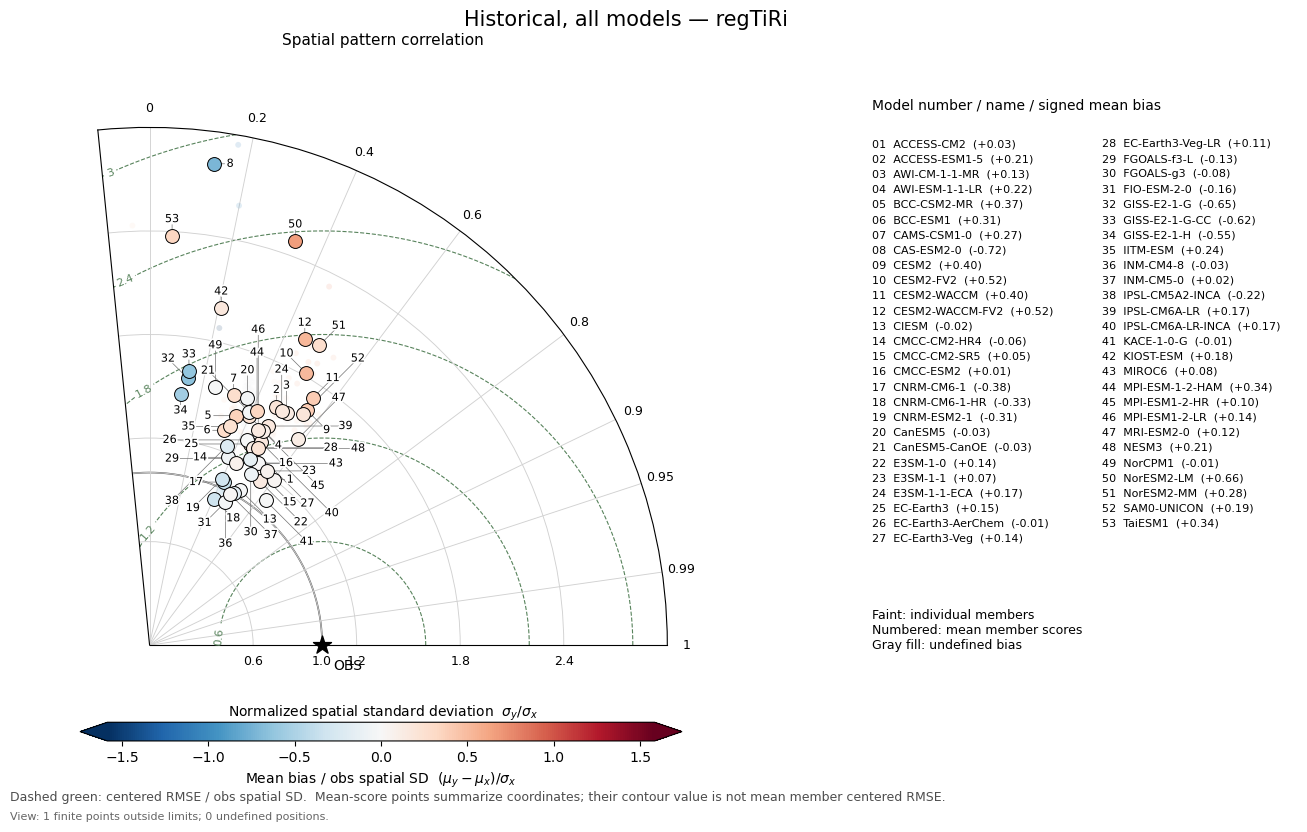

In [8]:
# Fixed-size numbered model means; color represents signed bias.
# Faint members use their own biases, not their model's mean bias.
fig_taylor_historical, ax_taylor_historical, key_taylor_historical = plot_taylor_experiment(
    taylor_members, taylor_means, "historical", taylor_markers,
    title=f"Historical, all models — {taylor_metric}",
    bias_label=taylor_bias_label, bias_vlim=taylor_bias_vlim,
    large_group_bias="color", mean_size=100,
    member_alpha=0.15, member_size=18, zoom=False,
    corr_min=-0.1,rmax=3,
)
# display(key_taylor_historical)             # Exact numbered values and in_view flags.
# fig_taylor_historical.savefig(f"/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/Taylor/taylor_historical_all_{taylor_metric}.png", 
#                                 dpi=300, bbox_inches="tight")
plt.show()


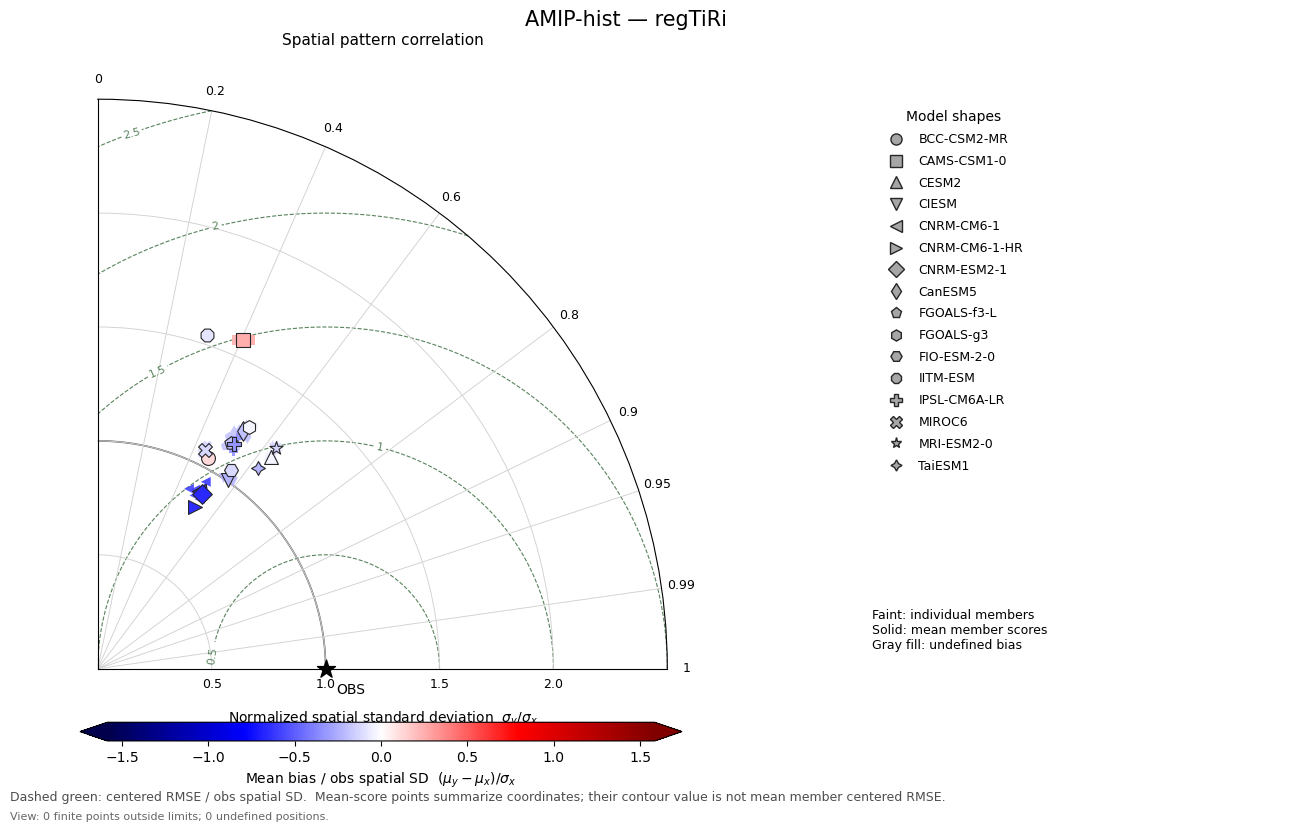

In [5]:
fig_taylor_amip, ax_taylor_amip, key_taylor_amip = plot_taylor_experiment(
    taylor_members, taylor_means, "amip_hist", taylor_markers,
    title=f"AMIP-hist — {taylor_metric}", bias_label=taylor_bias_label, bias_vlim=taylor_bias_vlim,
    rmax=2.5, corr_min=None, zoom=False, 
    member_alpha=0.9, member_size=50, mean_size=100, cmap="seismic",
)
# fig_taylor_amip.savefig("/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/Taylor/taylor_amip_regTiRi.png", dpi=300, bbox_inches="tight")
plt.show()

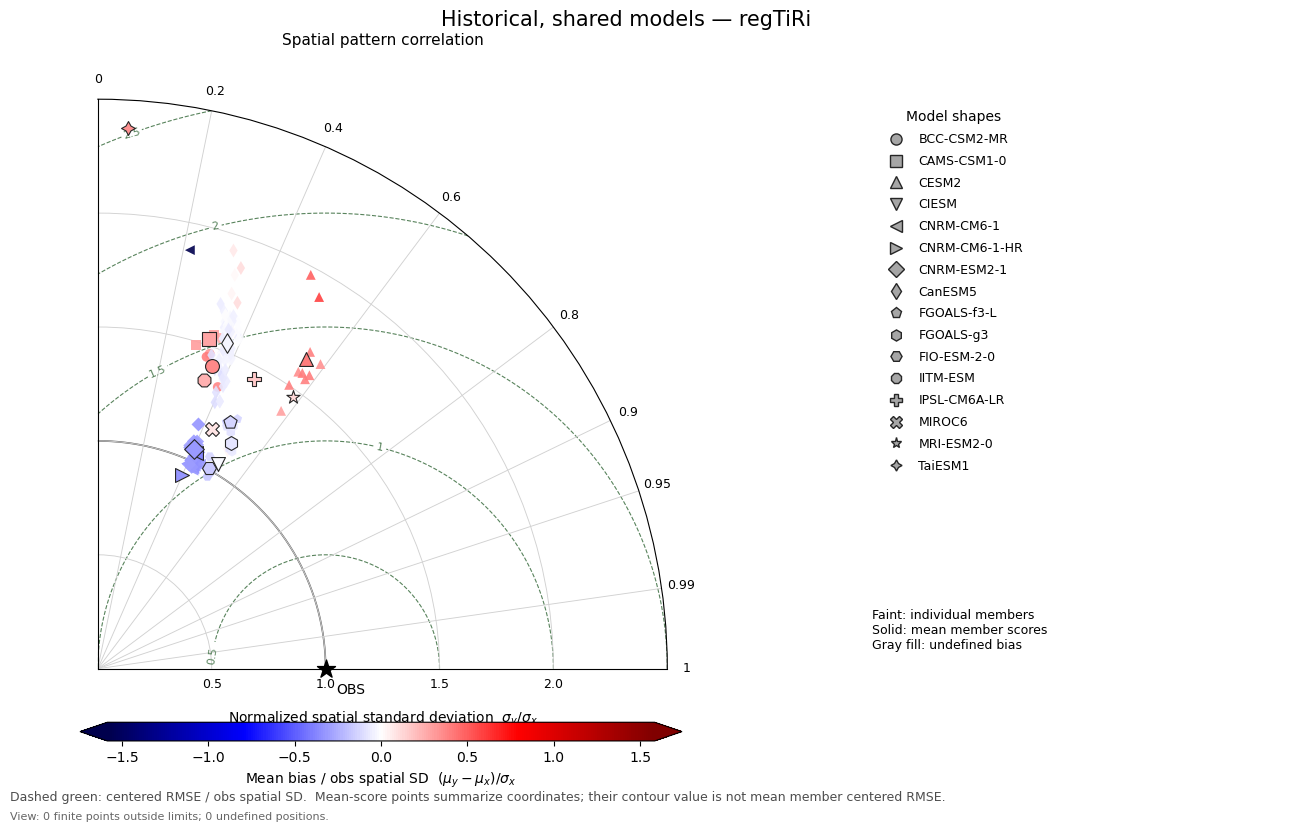

In [6]:
fig_taylor_matched, ax_taylor_matched, key_taylor_matched = plot_taylor_experiment(
    taylor_members, taylor_means, "historical_matched", taylor_markers,
    title=f"Historical, shared models — {taylor_metric}", bias_label=taylor_bias_label,
    bias_vlim=taylor_bias_vlim, rmax=2.5, corr_min=None, zoom=False, 
    member_alpha=0.9, member_size=50, mean_size=100, cmap="seismic",
)
# fig_taylor_matched.savefig("/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/Taylor/taylor_historical_matched_regTiRi.png", 
#                               dpi=300, bbox_inches="tight")
plt.show()

/tmp/ipykernel_205426/3209324653.py:343: UserWarning: Chosen extent hides 1 of 32 finite points; means still use all members.
  fig, ax, key_ax, visible = taylor_background(points, title, rmax=rmax, corr_min=corr_min,


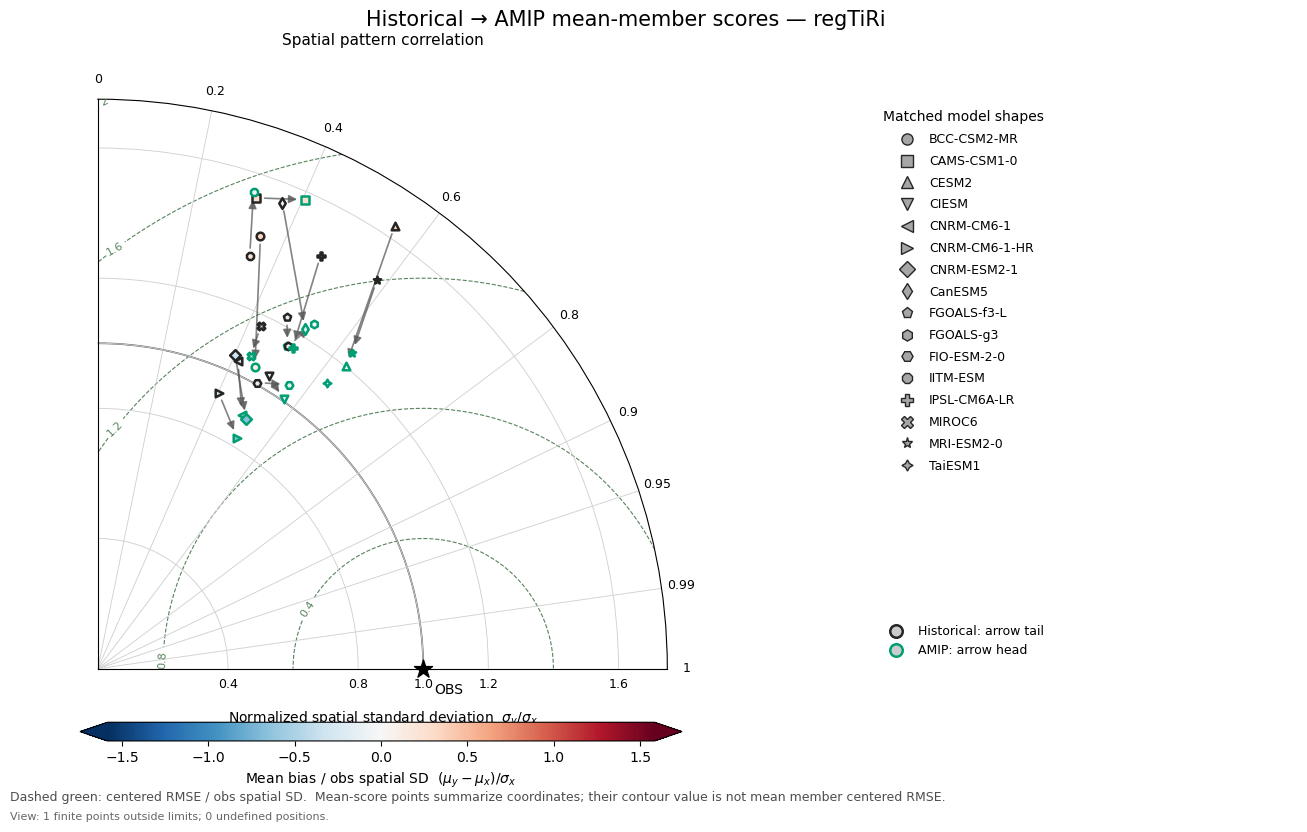

In [7]:
fig_taylor_shift, ax_taylor_shift, taylor_pairs = plot_taylor_shift(
    taylor_means, taylor_markers, title=f"Historical → AMIP mean-member scores — {taylor_metric}",
    bias_label=taylor_bias_label, bias_vlim=taylor_bias_vlim, 
    cmap="RdBu_r", rmax=1.75, corr_min=None, zoom=False,
    rms_levels=None, mean_size=30,
    historical_edge="#252525", amip_edge="#009E73"
)
# display(taylor_pairs)                      # Paired by model name, with arrow_drawn flags.
# fig_taylor_shift.savefig("/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/Taylor/taylor_historical_to_amip_regTiRi.png", 
#                         dpi=300, bbox_inches="tight")
plt.show()


/tmp/ipykernel_205426/3209324653.py:410: UserWarning: Chosen extent hides 1 of 32 finite points; means still use all members.
  fig, ax, key_ax, visible = taylor_background(


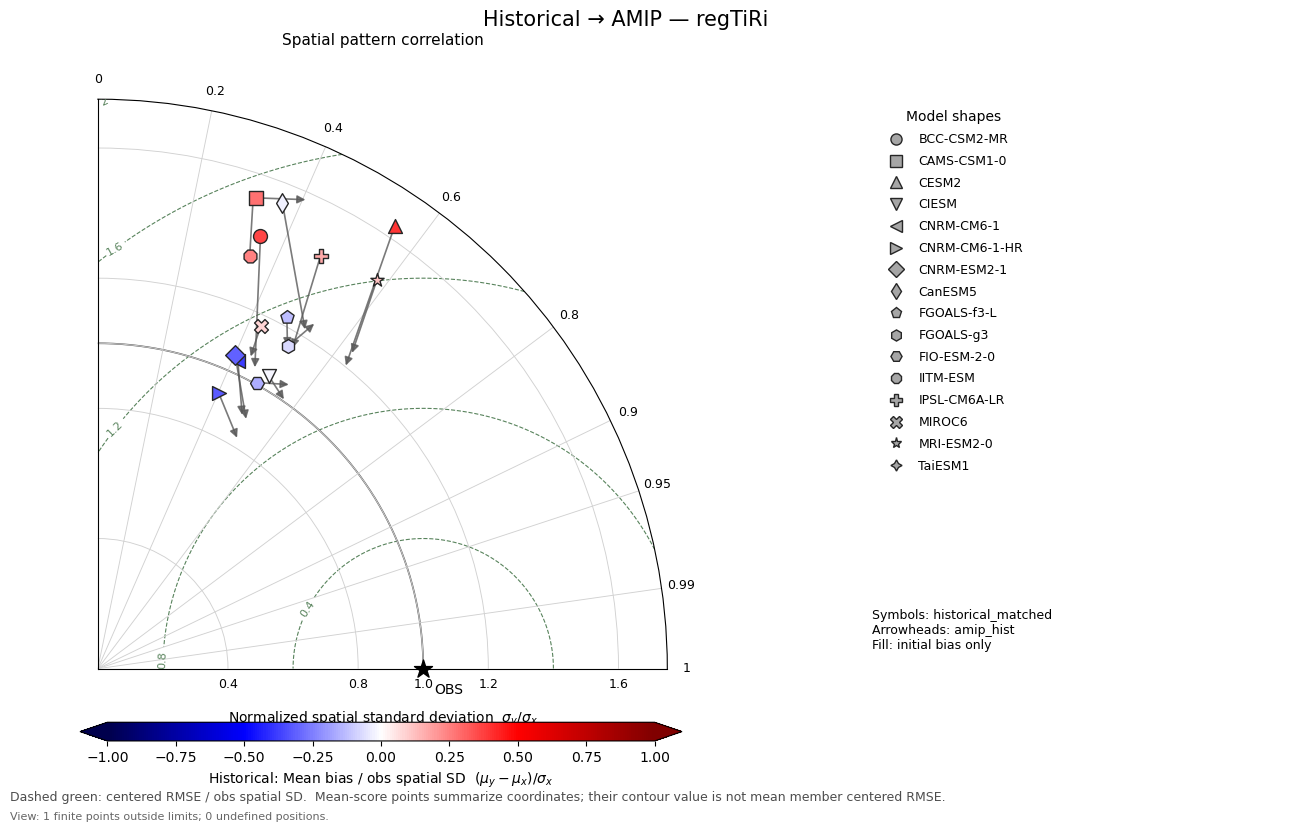

In [8]:
# Historical symbols → AMIP arrowheads, with no AMIP endpoint symbols.
fig_taylor_origins, ax_taylor_origins, taylor_origin_pairs = plot_taylor_origin_arrows(
    taylor_means, taylor_markers,
    initial="historical_matched", final="amip_hist",
    title=f"Historical → AMIP — {taylor_metric}",
    bias_label=f"Historical: {taylor_bias_label}", bias_vlim=1,
    cmap="seismic", rmax=1.75, corr_min=None, zoom=False,
    rms_levels=None, mean_size=100,
)
# fig_taylor_origins.savefig("/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/Taylor/taylor_historical_to_amip_arrows_regTiRi.png", 
#                         dpi=300, bbox_inches="tight")
plt.show()

In [9]:
# Select ONE diagnostic for all four figures. Switch to "covRTi" and rerun this
# cell and the four plot cells for the other diagnostic. No maps are recomputed.
taylor_metric = "covRTi"                  # Or "covRTi"
taylor_bias_key = "bias_over_std_x"        # Dimensionless signed bias, matching Taylor normalization.
taylor_bias_label = r"Mean bias / obs spatial SD  $(\mu_y-\mu_x)/\sigma_x$"

taylor_members, taylor_means = prepare_taylor_tables(
    member_scores, mean_member_scores, taylor_metric, bias_key=taylor_bias_key
)

# IMPORTANT: this sigma_x is the spatial SD of the OBS DIAGNOSTIC MAP, not the
# temporal temperature SD used when constructing regTiRi/covRTi in the first place.
# All input scores should use the same spatial domain/weights. Pairwise masks
# cannot be reconciled by plotting; use a common mask upstream when needed.
amip_names = list(member_scores["amip_hist"][taylor_metric])
matched_names = list(member_scores["historical_matched"][taylor_metric])
if set(amip_names) != set(matched_names):
    raise ValueError("Expected the same model set for AMIP and historical_matched.")
taylor_markers = {model: TAYLOR_SHAPES[i] for i, model in enumerate(amip_names[:16])}
# If a different <=16-model group contains additional names, give it its own
# available shapes while preserving assignments for models already in AMIP.
for experiment in ["historical_matched", "historical"]:
    names = list(member_scores[experiment][taylor_metric])
    if len(names) <= 16:
        used = {repr(taylor_markers[name]) for name in names if name in taylor_markers}
        remaining = [shape for shape in TAYLOR_SHAPES if repr(shape) not in used]
        for name in names:
            if name not in taylor_markers:
                taylor_markers[name] = remaining.pop(0)

# Use the SAME bias color scale in AMIP, matched historical, and the arrow plot.
# Default: include all finite member and mean biases in the two matched groups.
# Set taylor_bias_vlim manually if wanted; colorbar extensions mark saturation.
matched_bias = pd.concat([
    taylor_members.loc[taylor_members["experiment"].isin(["amip_hist", "historical_matched"]), "bias"],
    taylor_means.loc[taylor_means["experiment"].isin(["amip_hist", "historical_matched"]), "bias"]
]).to_numpy()
finite_bias = np.abs(matched_bias[np.isfinite(matched_bias)])
taylor_bias_vlim = float(finite_bias.max()) if finite_bias.size and finite_bias.max() > 0 else 1.0
# taylor_bias_vlim = 2.0

# Equal rmax/corr_min values across calls make separate diagrams directly
# comparable visually. None uses full-data bounds for each figure independently.
# zoom=True trims unused angular space. Manual rmax/corr_min may exclude points,
# but never changes the averages, and the figure reports exclusions.




In [28]:
taylor_metric

'covRTi'

/tmp/ipykernel_214135/1554433202.py:254: UserWarning: Chosen extent hides 4 of 313 finite points; means still use all members.
  fig, ax, key_ax, visible = taylor_background(points, title, rmax=rmax, corr_min=corr_min,


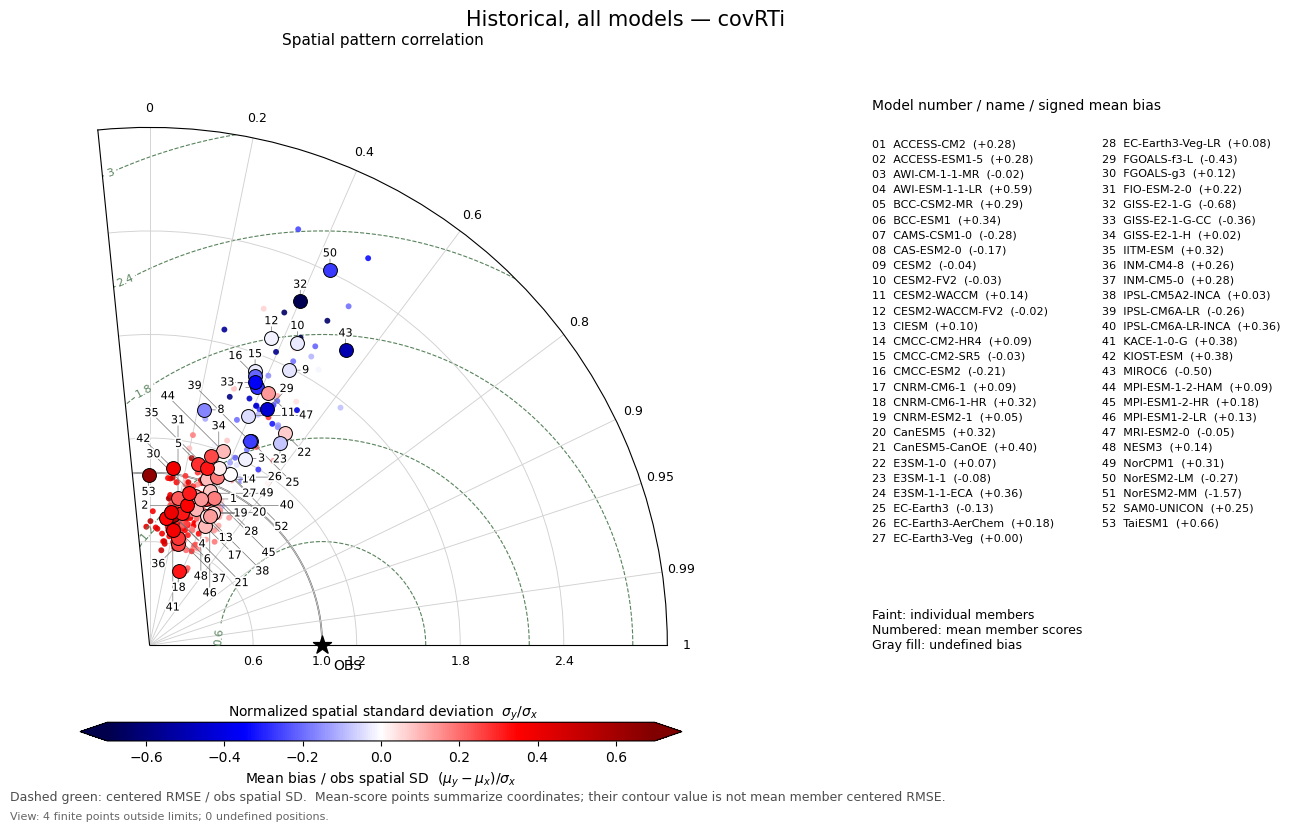

In [11]:
# Fixed-size numbered model means; color represents signed bias.
# Faint members use their own biases, not their model's mean bias.
fig_taylor_historical, ax_taylor_historical, key_taylor_historical = plot_taylor_experiment(
    taylor_members, taylor_means, "historical", taylor_markers,
    title=f"Historical, all models — {taylor_metric}",
    bias_label=taylor_bias_label, bias_vlim=taylor_bias_vlim,
    large_group_bias="color", mean_size=100,
    member_alpha=0.9, member_size=18, zoom=False,
    corr_min=-0.1,rmax=3, cmap='seismic',
)
# display(key_taylor_historical)             # Exact numbered values and in_view flags.
fig_taylor_historical.savefig(f"/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/Taylor/taylor_historical_all_{taylor_metric}.png", 
                                dpi=300, bbox_inches="tight")
plt.show()

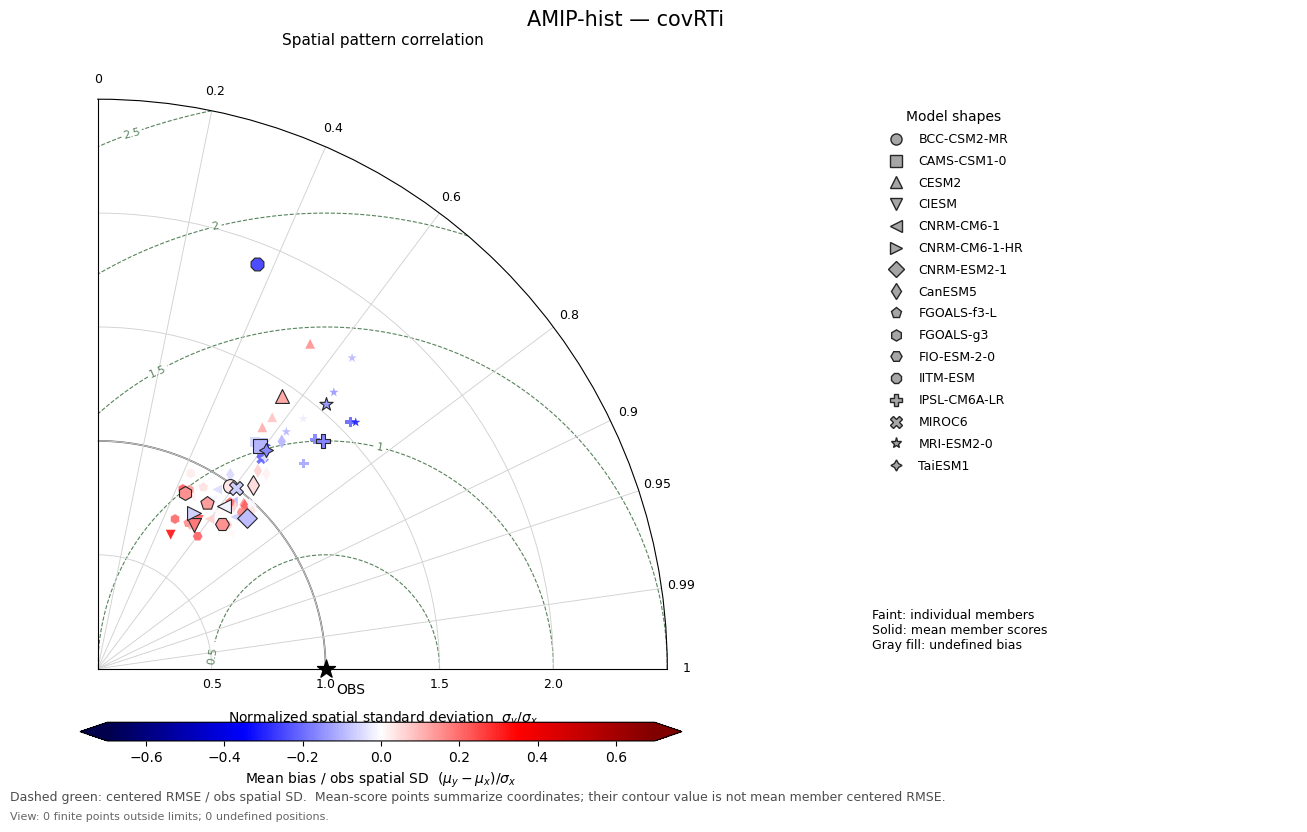

In [29]:
fig_taylor_amip, ax_taylor_amip, key_taylor_amip = plot_taylor_experiment(
    taylor_members, taylor_means, "amip_hist", taylor_markers,
    title=f"AMIP-hist — {taylor_metric}", bias_label=taylor_bias_label, bias_vlim=taylor_bias_vlim,
    rmax=2.5, corr_min=None, zoom=False, 
    member_alpha=0.9, member_size=50, mean_size=100, cmap="seismic",
)
fig_taylor_amip.savefig(f"/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/Taylor/taylor_amip_{taylor_metric}.png", dpi=300, bbox_inches="tight")
plt.show()

/tmp/ipykernel_148865/3209324653.py:251: UserWarning: Chosen extent hides 1 of 158 finite points; means still use all members.
  fig, ax, key_ax, visible = taylor_background(points, title, rmax=rmax, corr_min=corr_min,


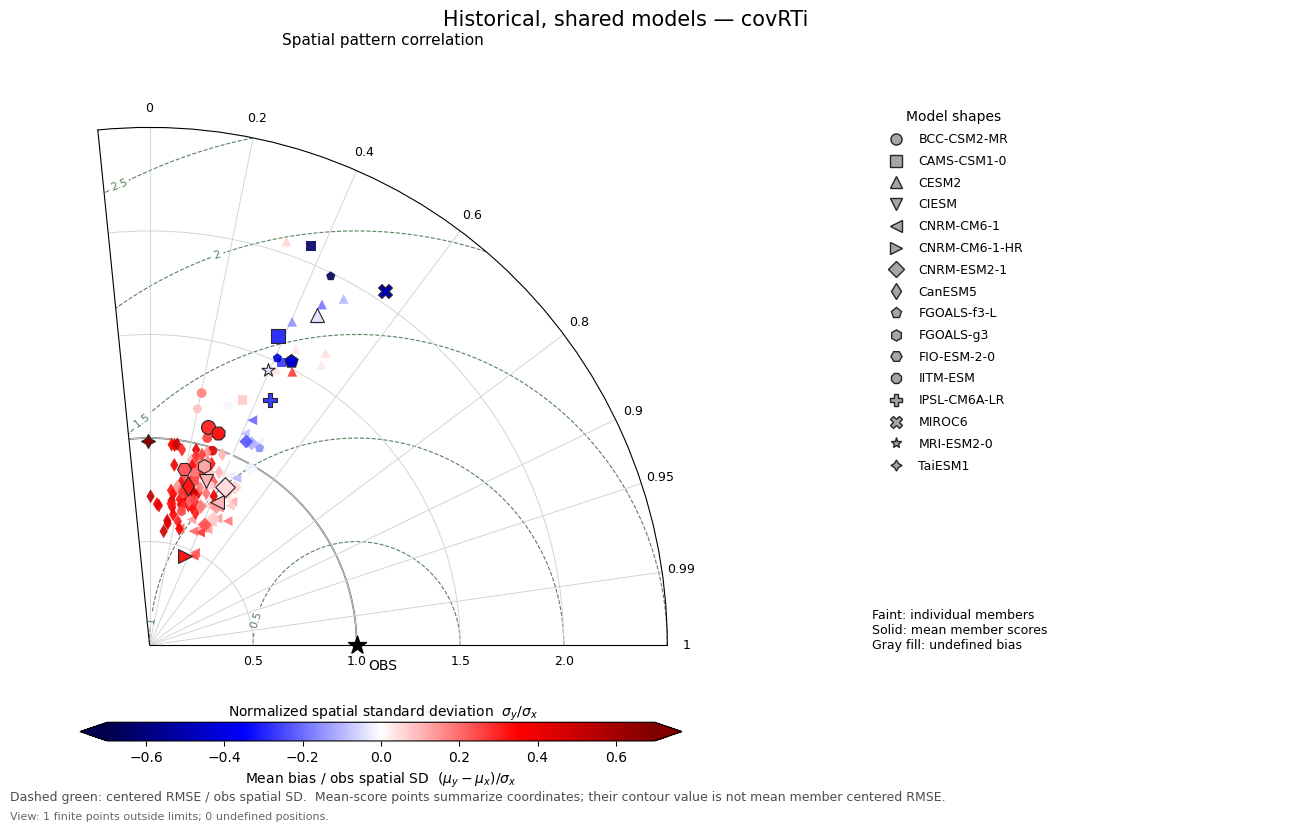

In [31]:
fig_taylor_matched, ax_taylor_matched, key_taylor_matched = plot_taylor_experiment(
    taylor_members, taylor_means, "historical_matched", taylor_markers,
    title=f"Historical, shared models — {taylor_metric}", bias_label=taylor_bias_label,
    bias_vlim=taylor_bias_vlim, rmax=2.5, corr_min=-0.1, zoom=False, 
    member_alpha=0.9, member_size=50, mean_size=100, cmap="seismic",
)
fig_taylor_matched.savefig(f"/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/Taylor/taylor_historical_matched_{taylor_metric}.png", 
                            dpi=300, bbox_inches="tight")
plt.show()

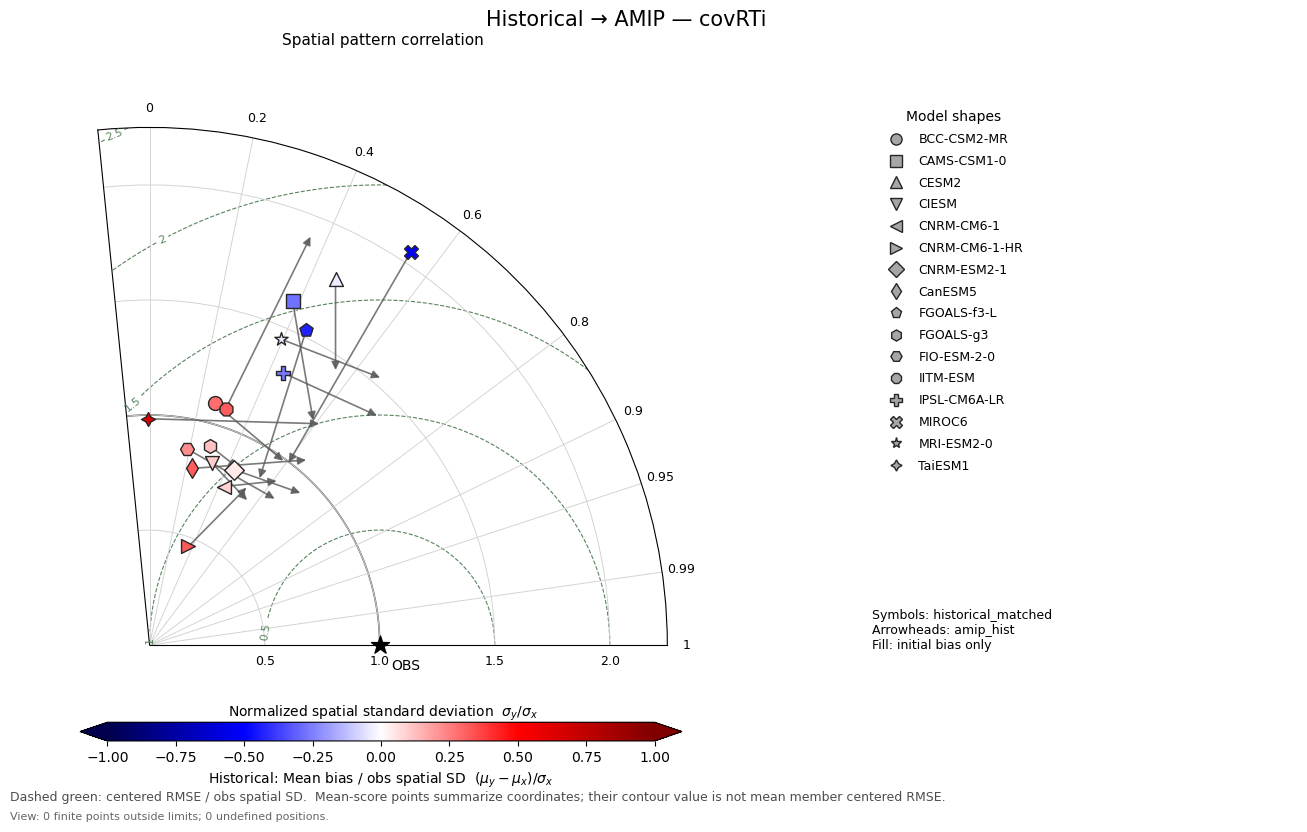

In [24]:
# Historical symbols → AMIP arrowheads, with no AMIP endpoint symbols.
fig_taylor_origins, ax_taylor_origins, taylor_origin_pairs = plot_taylor_origin_arrows(
    taylor_means, taylor_markers,
    initial="historical_matched", final="amip_hist",
    title=f"Historical → AMIP — {taylor_metric}",
    bias_label=f"Historical: {taylor_bias_label}", bias_vlim=1,
    cmap="seismic", rmax=2.25, corr_min=-0.1, zoom=False,
    rms_levels=None, mean_size=100,
)
# fig_taylor_origins.savefig(f"/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/Taylor/taylor_historical_to_amip_arrows_{taylor_metric}.png", 
#                         dpi=300, bbox_inches="tight")
plt.show()

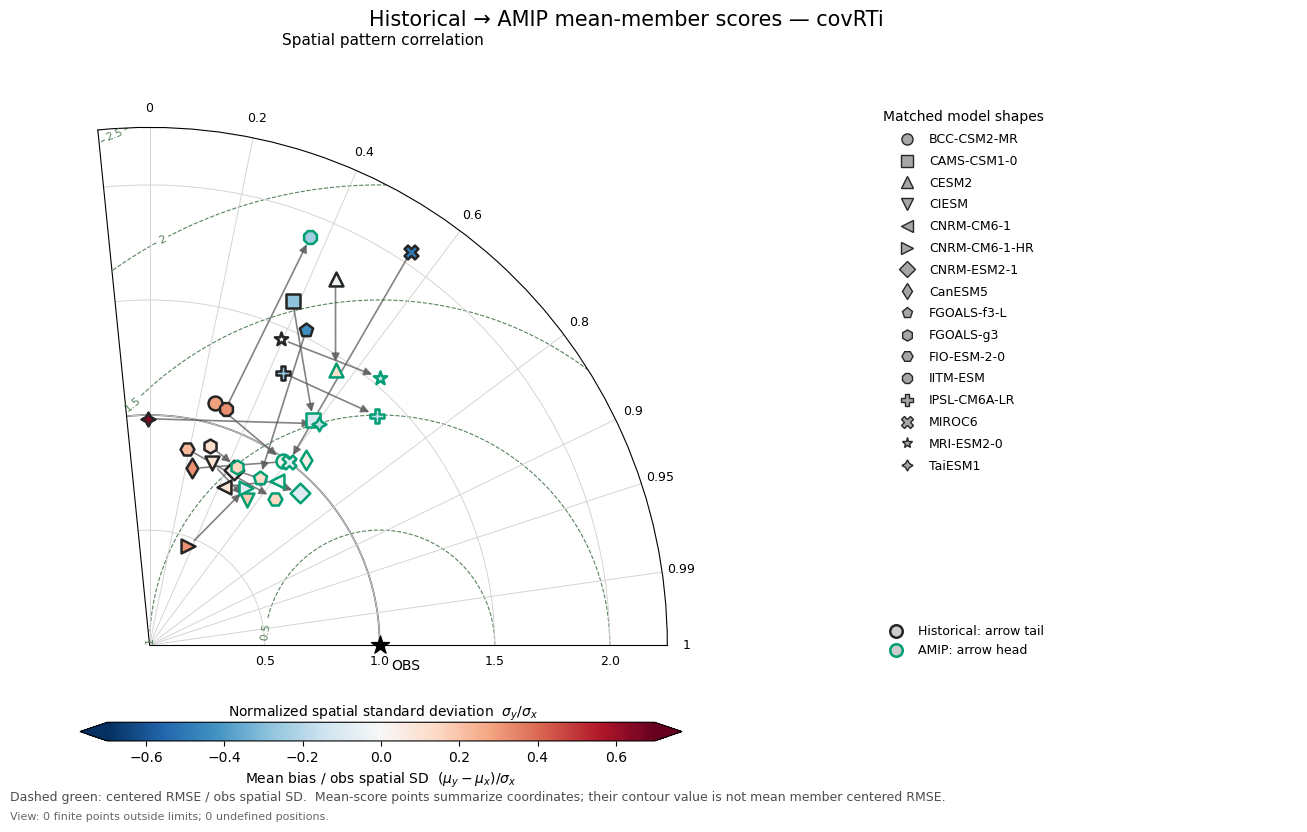

In [23]:
fig_taylor_shift, ax_taylor_shift, taylor_pairs = plot_taylor_shift(
    taylor_means, taylor_markers, title=f"Historical → AMIP mean-member scores — {taylor_metric}",
    bias_label=taylor_bias_label, bias_vlim=taylor_bias_vlim, 
    cmap="RdBu_r", rmax=2.25, corr_min=-0.1, zoom=False,
    rms_levels=None, mean_size=100,
    historical_edge="#252525", amip_edge="#009E73"
)
# display(taylor_pairs)                      # Paired by model name, with arrow_drawn flags.
# fig_taylor_shift.savefig(f"/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/Taylor/taylor_historical_to_amip_{taylor_metric}.png", 
#                         dpi=300, bbox_inches="tight")
plt.show()


In [13]:
# Little janky but this block gives us important common info
filepath_output_era5    = '/scratch/leiff/MCA/amip_clean/data/ERA5/tas_194001-202412_g025.nc'
ERA5                    = xc.open_dataset(filepath_output_era5).sel(time=slice('2000-03','2014-12')).rename_vars({
                            "t2m": "tas",})
ERA5['weights']         = ERA5['tas'][0]*0 + np.cos(np.deg2rad(ERA5.lat))
lat = ERA5.lat
lon = ERA5.lon

n_lat       = len(ERA5.lat)
n_lon       = len(ERA5.lon)
n_flat      = n_lat*n_lon
n_time      = len(ERA5.time)
lat_dim, lon_dim, ddof = "lat", "lon", 1

# Fix one area measure for all models/members. Zero or invalid weights exclude cells.
# If weights have coordinate labels, check them against each model grid below.
weights_input = ERA5["weights"]
if isinstance(weights_input, xr.DataArray):
    weights_input = weights_input.transpose(lat_dim, lon_dim)
weights = np.asarray(weights_input, dtype=float)
support = np.isfinite(weights) & (weights > 0)
if not support.any():
    raise ValueError("No positive finite area weights remain.")
area_weights = np.where(support, weights, 0.)
area_weights = area_weights / area_weights.sum()
weights_1D   = np.array(area_weights).reshape(n_flat)

ACCESS-CM2: 3/3 members used
ACCESS-ESM1-5: 30/30 members used
AWI-CM-1-1-MR: 5/5 members used
AWI-ESM-1-1-LR: 1/1 members used
BCC-CSM2-MR: 3/3 members used
BCC-ESM1: 3/3 members used
CAMS-CSM1-0: 3/3 members used
CAS-ESM2-0: 4/4 members used
CESM2: 11/11 members used
CESM2-FV2: 3/3 members used
CESM2-WACCM: 3/3 members used
CESM2-WACCM-FV2: 3/3 members used
CIESM: 3/3 members used
CMCC-CM2-HR4: 1/1 members used
CMCC-CM2-SR5: 1/1 members used
CMCC-ESM2: 1/1 members used
CNRM-CM6-1: 29/29 members used
CNRM-CM6-1-HR: 1/1 members used
CNRM-ESM2-1: 10/10 members used
CanESM5: 65/65 members used
CanESM5-CanOE: 3/3 members used
E3SM-1-0: 5/5 members used
E3SM-1-1: 1/1 members used
E3SM-1-1-ECA: 1/1 members used
EC-Earth3: 23/23 members used
EC-Earth3-AerChem: 1/1 members used
EC-Earth3-Veg: 6/6 members used
EC-Earth3-Veg-LR: 3/3 members used
FGOALS-f3-L: 3/3 members used
FGOALS-g3: 6/6 members used
FIO-ESM-2-0: 3/3 members used
GISS-E2-1-G: 1/1 members used
GISS-E2-1-G-CC: 1/1 members used


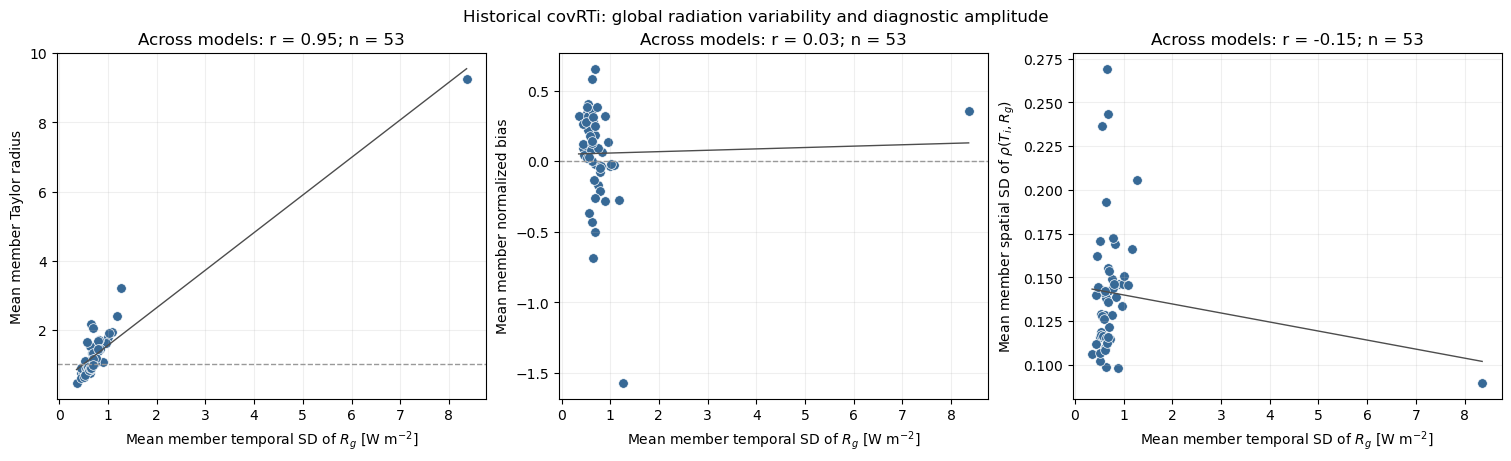

In [14]:
# %% Does global radiation variability explain covRTi's spatial amplitude?
# Requires member_scores, area_weights, and your existing detrend_monthly_fast.
# Use the same period, weights, preprocessing, and temporal ddof as for covRTi.
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path

rg_data_root = Path("/scratch/leiff/MCA/amip_clean/data")
rg_ddof = 1                         # Must match the covariance-map calculation.
rg_scores = member_scores["historical"]["covRTi"]
rg_models = list(rg_scores)

# Locate combined historical N files without assuming a particular subfolder.
# Require one file per model; ambiguous matches are reported rather than guessed.
rg_files = list(rg_data_root.rglob("N_Amon_*historical*combined*_g025.nc"))
rg_weights = np.asarray(area_weights, dtype=float)
if np.any(rg_weights < 0) or not np.any(np.isfinite(rg_weights) & (rg_weights > 0)):
    raise ValueError("Area weights must be nonnegative, with some positive finite weights.")
rg_weights = np.where(np.isfinite(rg_weights), rg_weights, 0.)
rg_weights = rg_weights / rg_weights.sum()
sigma_Rg_historical, Rg_member_ids_historical, rg_rows = {}, {}, []

# Calculate temporal SD separately for EVERY member, never from an ensemble-mean
# time series. File member order must match your saved member_scores; counts are
# checked below. area_weights must be on the same ordered lat/lon grid as N.
for model in rg_models:
    matches = [path for path in rg_files if path.name.startswith(f"N_Amon_{model}_")]
    if len(matches) != 1:
        raise ValueError(f"{model}: expected one historical N file; found {matches}. Check rg_data_root/glob.")
    with xr.open_dataset(matches[0]) as ds:
        radiation = ds["N"].sel(time=slice("2000-03", "2014-12"))
        ensemble_dims = [d for d in radiation.dims if d not in ("time", "lat", "lon")]
        if len(ensemble_dims) > 1:
            raise ValueError(f"{model}: select extra dimensions first: {radiation.dims}")
        radiation = (radiation.rename({ensemble_dims[0]: "member"}) if ensemble_dims
                     else radiation.expand_dims(member=["single"]))
        months = np.asarray(radiation.time.dt.year * 12 + radiation.time.dt.month - 1)
        if not np.array_equal(months, np.arange(2000 * 12 + 2, 2015 * 12)):
            raise ValueError(f"{model}: expected 178 consecutive months, March 2000–December 2014.")
        if radiation.sizes["member"] != len(rg_scores[model]["contrast_ratio"]):
            raise ValueError(f"{model}: file and saved scores have different member counts.")
        weights = xr.DataArray(rg_weights, dims=("lat", "lon"), coords={d: radiation[d] for d in ("lat", "lon")})
        Rg_member_ids_historical[model] = radiation.member.values.copy()
        member_sigma = []

        # With complete data and fixed weights, linear monthly-anomaly/detrend
        # operations commute with spatial averaging. Process the global index as
        # in your original loop; do not take an area mean of LOCAL radiation SDs.
        for e in range(radiation.sizes["member"]):
            field = radiation.isel(member=e).where(weights > 0, 0.)
            global_raw = (field * weights).sum(("lat", "lon"), skipna=False).values
            if not np.isfinite(global_raw).all():
                raise ValueError(f"{model}, member {e}: missing radiation on the fixed global support.")
            global_anomaly = np.asarray(detrend_monthly_fast(global_raw), dtype=float)
            if global_anomaly.shape != (178,) or not np.isfinite(global_anomaly).all():
                raise ValueError(f"{model}, member {e}: check detrend_monthly_fast output.")
            member_sigma.append(np.std(global_anomaly, ddof=rg_ddof))

    # Remove the common radiation-amplitude factor BEFORE averaging members:
    # covRTi_i = sigma(Rg) * rho(T_i, Rg), so std_space(covRTi) / sigma(Rg)
    # equals std_space(rho). This third quantity retains correlation-map contrast.
    sigma = np.asarray(member_sigma)
    sigma_Rg_historical[model] = sigma
    radius = np.asarray(rg_scores[model]["contrast_ratio"], dtype=float)
    bias = np.asarray(rg_scores[model]["bias_over_std_x"], dtype=float)
    map_sd = np.asarray(rg_scores[model]["std_y"], dtype=float)
    valid = (sigma > 0) & np.isfinite(sigma) & np.isfinite(radius) & np.isfinite(bias) & np.isfinite(map_sd)
    if valid.any():
        rg_rows.append(dict(model=model, sigma_Rg=sigma[valid].mean(), radius=radius[valid].mean(),
                            bias=bias[valid].mean(), rho_spatial_sd=(map_sd[valid] / sigma[valid]).mean(),
                            n_members=int(valid.sum())))
    print(f"{model}: {valid.sum()}/{len(sigma)} members used")

# One point and one vote per model. Use the same finite members for all columns;
# with no missing scores, radius/bias equal your saved mean_member_scores values.
Rg_diagnostic_check = pd.DataFrame(rg_rows)
if Rg_diagnostic_check.empty:
    raise ValueError("No valid model summaries remain.")
fig_Rg_check, axes_Rg_check = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)
Rg_check_stats = {}
panels = [("radius", "Mean member Taylor radius"), ("bias", "Mean member normalized bias"),
          ("rho_spatial_sd", r"Mean member spatial SD of $\rho(T_i,R_g)$")]


for ax, (key, label) in zip(axes_Rg_check, panels):
    x, y = Rg_diagnostic_check["sigma_Rg"].to_numpy(), Rg_diagnostic_check[key].to_numpy()
    ax.scatter(x, y, s=48, color="#376996", edgecolors="white", linewidths=0.5)
    result = stats.linregress(x, y) if len(x) >= 2 and np.ptp(x) > 0 and np.ptp(y) > 0 else None
    r = result.rvalue if result is not None else np.nan
    if result is not None:
        line_x = np.array([x.min(), x.max()])
        ax.plot(line_x, result.intercept + result.slope * line_x, color="0.3", linewidth=1)
    Rg_check_stats[key] = dict(r=r, r_squared=r**2, n_models=len(x))
    ax.set(xlabel=r"Mean member temporal SD of $R_g$ [W m$^{-2}$]", ylabel=label)
    ax.set_title(f"Across models: r = {r:.2f}; n = {len(x)}")
    ax.grid(alpha=0.2)
axes_Rg_check[0].axhline(1, color="0.6", linestyle="--", linewidth=1)
axes_Rg_check[1].axhline(0, color="0.6", linestyle="--", linewidth=1)
fig_Rg_check.suptitle("Historical covRTi: global radiation variability and diagnostic amplitude")
plt.show()


,model,sigma_Rg,radius,bias
23,E3SM-1-1-ECA,8.362604,9.264571,0.356075


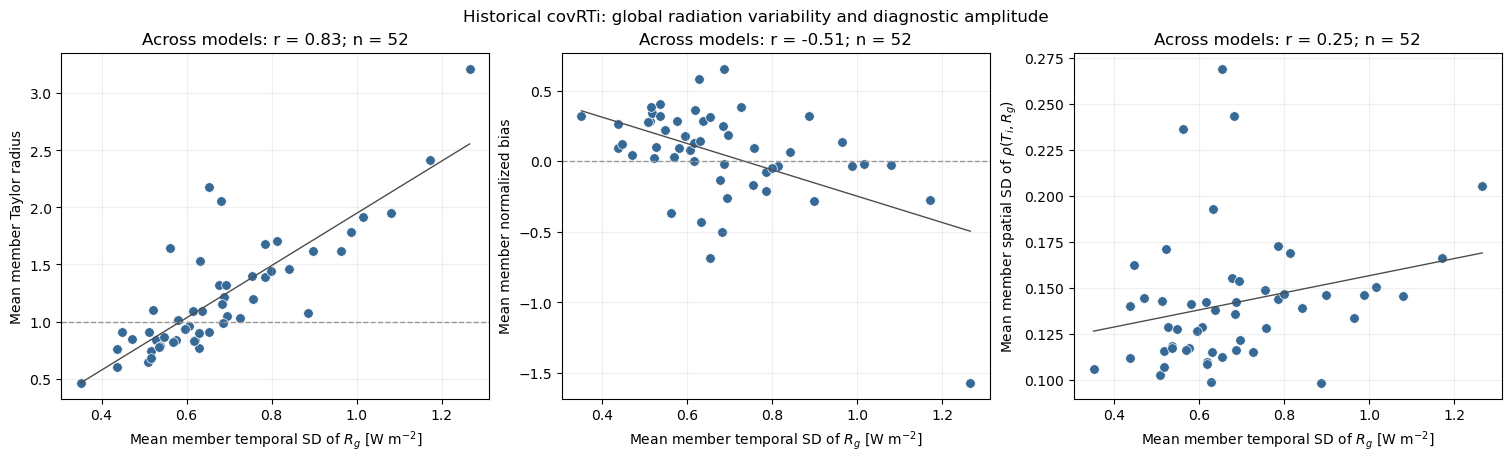

In [15]:
# One point and one vote per model. Use the same finite members for all columns;
# with no missing scores, radius/bias equal your saved mean_member_scores values.
Rg_diagnostic_check = pd.DataFrame(rg_rows)
if Rg_diagnostic_check.empty:
    raise ValueError("No valid model summaries remain.")
fig_Rg_check, axes_Rg_check = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)
Rg_check_stats = {}
panels = [("radius", "Mean member Taylor radius"), ("bias", "Mean member normalized bias"),
          ("rho_spatial_sd", r"Mean member spatial SD of $\rho(T_i,R_g)$")]

# Identify the outlier, retaining the original table for the full-data comparison.
rg_outliers = Rg_diagnostic_check["sigma_Rg"] > 2
display(Rg_diagnostic_check.loc[rg_outliers, ["model", "sigma_Rg", "radius", "bias"]])

# Exclude those models from a separate plotting/correlation table.
Rg_plot_data = Rg_diagnostic_check.loc[~rg_outliers].copy()


for ax, (key, label) in zip(axes_Rg_check, panels):
    x, y = Rg_plot_data["sigma_Rg"].to_numpy(), Rg_plot_data[key].to_numpy()
    ax.scatter(x, y, s=48, color="#376996", edgecolors="white", linewidths=0.5)
    result = stats.linregress(x, y) if len(x) >= 2 and np.ptp(x) > 0 and np.ptp(y) > 0 else None
    r = result.rvalue if result is not None else np.nan
    if result is not None:
        line_x = np.array([x.min(), x.max()])
        ax.plot(line_x, result.intercept + result.slope * line_x, color="0.3", linewidth=1)
    Rg_check_stats[key] = dict(r=r, r_squared=r**2, n_models=len(x))
    ax.set(xlabel=r"Mean member temporal SD of $R_g$ [W m$^{-2}$]", ylabel=label)
    ax.set_title(f"Across models: r = {r:.2f}; n = {len(x)}")
    ax.grid(alpha=0.2)
axes_Rg_check[0].axhline(1, color="0.6", linestyle="--", linewidth=1)
axes_Rg_check[1].axhline(0, color="0.6", linestyle="--", linewidth=1)
fig_Rg_check.suptitle("Historical covRTi: global radiation variability and diagnostic amplitude")
plt.show()

Interpretation: The correlation in the first suggests that the connection between bias and radius may just be that the cov map is corr(T_i,R)*std(R). So if std(R) is higher, then the mean and spatial contrast will be stronger. The second panel is consistent with a negative mean map, in that the stronger R std enhances the underlying negative corr. The third suggests that there is not much relationship with just corr(T_i,R) with std(R), so it is likely that the r in the left panel is due to the std(R) in the cov term

or chatgpt:
Interpretation: The strong relationship between global radiation variability and Taylor radius is consistent with the identity \(\operatorname{Cov}(Z_i,R_g)=\rho(T_i,R_g)\,\sigma(R_g)\). Holding the correlation pattern fixed, larger \(\sigma(R_g)\) increases the covariance map’s spatial contrast and the magnitude of its spatial mean. The negative association with bias is consistent with this scaling producing more negative covariance-map means where the underlying correlation map has a negative spatial mean. After removing the radiation-SD factor, the correlation map’s spatial contrast is only weakly associated with \(\sigma(R_g)\). Together, these results support the explicit radiation-amplitude factor as an important contributor to the radius differences and associated bias, but do not establish that it is the sole explanation.